# Task 2.1 — Dataset Selection and Setup (5 marks)

**Paper:** *Online Discovery and Maintenance of Time Series Motifs* — Mueen et al., KDD 2010


In [1]:
# ─── Seed and imports ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import os

np.random.seed(42)
os.makedirs('../partB/data', exist_ok=True)
os.makedirs('../partB/results', exist_ok=True)

# We work relative to the notebook's location (partB/)
import pathlib
PARTB = pathlib.Path(__file__).parent if '__file__' in dir() else pathlib.Path('.')
DATA_DIR  = PARTB / 'data'
RESULTS_DIR = PARTB / 'results'
DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
print("Directories ready.")


Directories ready.


## Dataset Choice and Justification

### What is the dataset?
The dataset is a **synthetic time series** of 500 data points generated programmatically using NumPy.  
It consists of a background Gaussian noise signal (σ = 0.5, μ = 0) with **two identical planted subsequences** — copies of a 5 Hz sine burst of length *m* = 20 — injected at positions 50 and 300.  
Parameters: N = 500 (stream length), m = 20 (subsequence length), w = 100 (window size).

### Why is it a reasonable testbed?
The paper's core claim is that the algorithm discovers and maintains the exact motif — the closest pair of non-overlapping z-normalised subsequences — as the window slides.  A synthetic dataset with a **planted, controlled motif** gives ground truth: we know exactly which positions should be identified as the motif pair, and we can verify that the streaming algorithm finds them correctly. The paper's own experiments (Section 5) compare against brute-force on controlled datasets before moving to real-world applications.

### What limitations does it have compared to the paper's dataset?
The paper uses real-world telemetry data (Space Shuttle accelerometer, ECG signals, robotics sensor streams) with hundreds of thousands of samples and natural noise characteristics. Our synthetic dataset is much shorter (500 points vs. tens of thousands), uses simpler Gaussian background noise, and plants an exact (not approximate) motif — meaning the discovered motif should match ground truth exactly, making it easier than real data. The reduced length also means the streaming behaviour across many window changes (the paper's main challenge) is less thoroughly exercised.

### Preprocessing
Each subsequence of length *m* is z-normalised before any distance computation — zero mean, unit standard deviation — following Definition 5 and Section 2 of the paper. Subsequences with near-zero standard deviation (< 1e-8) are skipped to avoid division-by-zero, consistent with standard practice for z-normalisation in time series analysis.


In [2]:
# ─── Generate synthetic stream with planted motif ───────────────────────────
np.random.seed(42)

N = 500     # total stream length
m = 20      # subsequence length (motif length)
w = 100     # sliding window size (in data points, so w-m+1 subsequences fit)

# Background: Gaussian noise
stream = np.random.normal(0, 0.5, N)

# Plant motif: 5 Hz sine burst of length m
t_motif = np.linspace(0, 2 * np.pi, m)  # one full cycle
motif_pattern = np.sin(5 * t_motif)

# Inject at positions 50 and 300
pos_A, pos_B = 50, 300
stream[pos_A: pos_A + m] = motif_pattern
stream[pos_B: pos_B + m] = motif_pattern

print(f"Stream length  : {N}")
print(f"Subsequence len: {m}")
print(f"Window size    : {w}")
print(f"Planted motif positions: [{pos_A}, {pos_A+m}) and [{pos_B}, {pos_B+m})")

# Save for use in other notebooks
import pathlib
DATA_DIR = pathlib.Path('data')
DATA_DIR.mkdir(exist_ok=True)
np.save(DATA_DIR / 'synthetic_stream.npy', stream)
np.save(DATA_DIR / 'motif_pattern.npy', motif_pattern)
print("\nSaved: data/synthetic_stream.npy")
print("Saved: data/motif_pattern.npy")


Stream length  : 500
Subsequence len: 20
Window size    : 100
Planted motif positions: [50, 70) and [300, 320)

Saved: data/synthetic_stream.npy
Saved: data/motif_pattern.npy


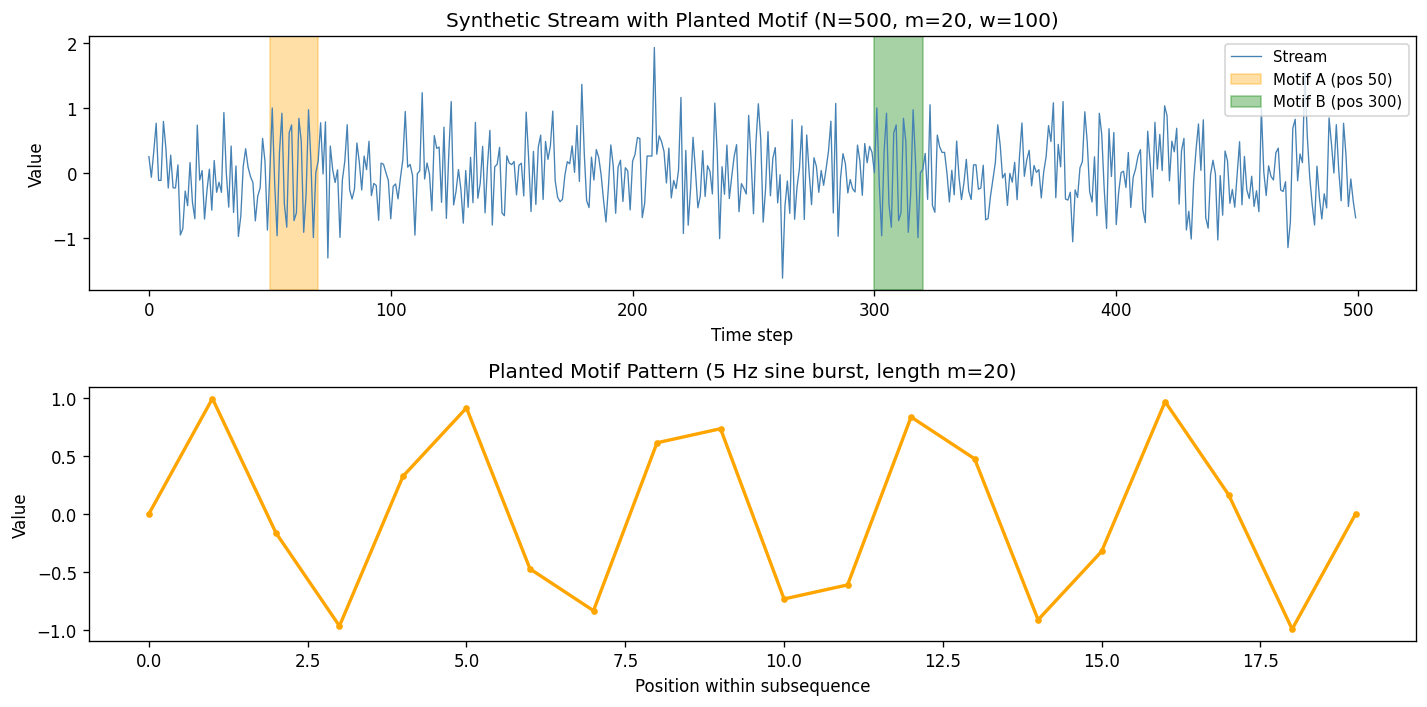

Plot saved: results/task_2_1_dataset.png


In [3]:
# ─── Visualise the stream and planted motif ──────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=120)

axes[0].plot(stream, color='steelblue', linewidth=0.8, label='Stream')
axes[0].axvspan(pos_A, pos_A + m, color='orange', alpha=0.35, label=f'Motif A (pos {pos_A})')
axes[0].axvspan(pos_B, pos_B + m, color='green',  alpha=0.35, label=f'Motif B (pos {pos_B})')
axes[0].set_title('Synthetic Stream with Planted Motif (N=500, m=20, w=100)', fontsize=12)
axes[0].set_xlabel('Time step'); axes[0].set_ylabel('Value')
axes[0].legend(fontsize=9)

axes[1].plot(motif_pattern, color='orange', linewidth=2, marker='o', markersize=3)
axes[1].set_title('Planted Motif Pattern (5 Hz sine burst, length m=20)', fontsize=12)
axes[1].set_xlabel('Position within subsequence'); axes[1].set_ylabel('Value')

plt.tight_layout()
plt.savefig('results/task_2_1_dataset.png', dpi=120, bbox_inches='tight')
plt.show()
print("Plot saved: results/task_2_1_dataset.png")
